In [1]:
import copy
import numpy as np
import pandas as pd
import math
from pathlib import Path
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F

## Infra

### 1.数据加载

#### 1.1 PEMS04

* PEMS04有三个特征，07有一个特征，这里我们选择特征维度更丰富04
* 此外每个时间步都有几百个监测点的特征，这里我们取第一个监测点的特征作为输入，适配我们简单的序列模型

In [2]:
class PEMS04Dataset(Dataset):
    def __init__(self, data, seq_len=12, target_feature=0):
        """
        data shape: (time_steps, 3)
        x shape   : (seq_len, 3)
        y shape   : ()
        """
        if data.ndim != 2:
            raise ValueError(f"data 必须是 2 维，当前 shape={data.shape}")

        if seq_len <= 0:
            raise ValueError("seq_len 必须大于 0")

        total_steps, num_features = data.shape
        if total_steps < seq_len + 1:
            raise ValueError(
                f"时间长度不足，当前 total_steps={total_steps}，"
                f"但至少需要 seq_len + 1 = {seq_len + 1}"
            )

        if not (0 <= target_feature < num_features):
            raise ValueError(
                f"target_feature 越界: {target_feature}, "
                f"可选范围为 [0, {num_features - 1}]"
            )

        self.data = torch.as_tensor(data, dtype=torch.float32)
        self.seq_len = seq_len
        self.target_feature = target_feature
        self.num_samples = total_steps - seq_len

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.seq_len]  # (seq_len, 3)
        y = self.data[idx + self.seq_len, self.target_feature]  # scalar
        return x, y


def _load_pems04_sensor(data_path, sensor=0):
    data_path = Path(data_path)
    if not data_path.exists():
        raise FileNotFoundError(f"数据文件不存在: {data_path}")

    npz = np.load(data_path)
    if "data" not in npz:
        raise KeyError(f"{data_path} 中未找到 'data' 字段，实际字段为: {npz.files}")

    data = npz["data"].astype(np.float32)  # (16992, 307, 3)

    if data.ndim != 3:
        raise ValueError(f"原始数据必须是 3 维，当前 shape={data.shape}")

    if not (0 <= sensor < data.shape[1]):
        raise ValueError(
            f"sensor 越界: {sensor}, 可选范围为 [0, {data.shape[1] - 1}]"
        )

    return data[:, sensor, :]  # 只取第 sensor 个监测点，shape: (time_steps, 3)


def _split_time_series_data(data, train_ratio=0.6, val_ratio=0.2):
    if not 0.4 <= train_ratio <= 0.8:
        raise ValueError("train_ratio 必须在 0.4 到 0.8 之间")

    if not 0.1 <= val_ratio <= 0.3:
        raise ValueError("val_ratio 必须在 0.1 到 0.3 之间")

    total_steps = data.shape[0]
    train_steps = max(1, math.floor(total_steps * train_ratio))
    val_steps = max(1, math.floor(total_steps * val_ratio))

    train_data = data[:train_steps]
    val_data = data[train_steps : train_steps + val_steps]
    test_data = data[train_steps + val_steps :]
    return train_data, val_data, test_data


def _normalize_with_train_stats(train_data, val_data, test_data, eps=1e-6):
    min_ = train_data.min(axis=0, keepdims=True)
    max_ = train_data.max(axis=0, keepdims=True)
    span = max_ - min_
    span = np.where(span < eps, 1.0, span)

    train_data = (train_data - min_) / span
    val_data = (val_data - min_) / span
    test_data = (test_data - min_) / span

    stats = {
        "min": min_.astype(np.float32),
        "max": max_.astype(np.float32),
    }
    return train_data, val_data, test_data, stats


def get_pems04_dataloader(
    data_path="../data/PEMS04/PEMS04.npz",
    sensor=0,
    seq_len=12,
    batch_size=32,
    train_ratio=0.6,
    val_ratio=0.2,
    num_workers=0,
    shuffle_train=True,
    normalize=True,
    target_feature=0,
):
    data = _load_pems04_sensor(data_path, sensor=sensor)
    train_data, val_data, test_data = _split_time_series_data(
        data, train_ratio=train_ratio, val_ratio=val_ratio
    )

    stats = None
    if normalize:
        train_data, val_data, test_data, stats = _normalize_with_train_stats(
            train_data, val_data, test_data
        )

    train_dataset = PEMS04Dataset(
        train_data,
        seq_len=seq_len,
        target_feature=target_feature,
    )
    val_dataset = PEMS04Dataset(
        val_data,
        seq_len=seq_len,
        target_feature=target_feature,
    )
    test_dataset = PEMS04Dataset(
        test_data,
        seq_len=seq_len,
        target_feature=target_feature,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle_train,
        num_workers=num_workers,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    return train_loader, val_loader, test_loader, stats

In [3]:
train_loader, val_loader, test_loader, stats = get_pems04_dataloader(batch_size=16)
x, y = next(iter(train_loader))
print("x.shape =", x.shape)  # torch.Size([16, 12, 3])
print("y.shape =", y.shape)  # torch.Size([16])

x.shape = torch.Size([16, 12, 3])
y.shape = torch.Size([16])


#### 1.2 FS_NYC

> **特征选择说明**:预测目标为下一个签到的 `venueId`(多分类)。
> 输入包含两部分:
> 1. `venueId` 索引序列 → `nn.Embedding` 学习向量表示(venueId 是离散 ID,不能直接作为数值输入);
> 2. 经纬度 `(latitude, longitude)` 连续特征(z-score 归一化),与 embedding 拼接后进入 LSTM/GRU。
> 去掉 `timezoneOffset`——该列在 NYC 数据上几乎为常量(-240 占约 75%),判别信息很少。
> 数据按用户时间顺序切分为 train 60% / val 20% / test 20%,验证集用于早停,测试集仅在训练结束后评估一次。

In [4]:
class FSNYCDataset(Dataset):
    def __init__(self, cat_features, cont_features, labels):
        """
        cat_features  shape: (num_samples, seq_len)            -- venueId 索引序列(long)
        cont_features shape: (num_samples, seq_len, num_cont)  -- 经纬度等连续特征(float32)
        labels         shape: (num_samples,)
        """
        cat_features = torch.as_tensor(cat_features, dtype=torch.long)
        cont_features = torch.as_tensor(cont_features, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.long)

        if cat_features.ndim != 2:
            raise ValueError(
                f"cat_features 必须是 2 维，当前 shape={tuple(cat_features.shape)}"
            )

        if cont_features.ndim != 3:
            raise ValueError(
                f"cont_features 必须是 3 维，当前 shape={tuple(cont_features.shape)}"
            )

        if labels.ndim != 1:
            raise ValueError(f"labels 必须是 1 维，当前 shape={tuple(labels.shape)}")

        n = len(labels)
        if len(cat_features) != n or len(cont_features) != n:
            raise ValueError(
                f"样本数不一致: cat {len(cat_features)} / cont {len(cont_features)} / labels {n}"
            )

        self.cat_features = cat_features
        self.cont_features = cont_features
        self.labels = labels

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # 返回 ((venueId 索引序列, 连续特征序列), 标签)，模型输入为元组
        x = (self.cat_features[idx], self.cont_features[idx])
        y = self.labels[idx]
        return x, y


def _load_fs_nyc_dataframe(data_path):
    data_path = Path(data_path)
    if not data_path.exists():
        raise FileNotFoundError(f"数据文件不存在: {data_path}")

    df = pd.read_csv(data_path)

    required_columns = [
        "userId",
        "venueId",
        "latitude",
        "longitude",
        "timezoneOffset",
        "utcTimestamp",
    ]
    missing_columns = [col for col in required_columns if col not in df.columns]
    if missing_columns:
        raise KeyError(f"缺少必要列: {missing_columns}")

    df["utcTimestamp"] = pd.to_datetime(
        df["utcTimestamp"],
        format="%a %b %d %H:%M:%S %z %Y",
        utc=True,
    )

    df = df.sort_values(["userId", "utcTimestamp"]).reset_index(drop=True)
    return df


def _split_user_trajectories(df, train_ratio=0.6, val_ratio=0.2):
    """
    对每个用户按时间顺序切分 train / val / test:
    - 前 train_ratio 用于训练
    - 中间 val_ratio 用于验证(早停)
    - 剩余 1 - train_ratio - val_ratio 用于测试
    """
    if train_ratio <= 0 or val_ratio < 0 or train_ratio + val_ratio >= 1:
        raise ValueError("train_ratio、val_ratio 需满足 0 < train_ratio + val_ratio < 1")

    train_parts = []
    val_parts = []
    test_parts = []

    for _, group in df.groupby("userId", sort=False):
        n = len(group)
        train_count = math.floor(n * train_ratio)
        val_count = math.floor(n * val_ratio)

        train_parts.append(group.iloc[:train_count].copy())
        val_parts.append(group.iloc[train_count : train_count + val_count].copy())
        test_parts.append(group.iloc[train_count + val_count :].copy())

    train_df = pd.concat(train_parts, ignore_index=True)
    val_df = pd.concat(val_parts, ignore_index=True)
    test_df = pd.concat(test_parts, ignore_index=True)
    return train_df, val_df, test_df


def _normalize_features(train_df, val_df, test_df, feature_columns, eps=1e-6):
    """z-score 归一化:均值/标准差只从训练集统计,验证/测试集用同一组统计量。"""
    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()

    # 先把参与归一化的列统一转成 float32，避免 int64 列回写时报错
    for df in (train_df, val_df, test_df):
        df[feature_columns] = df[feature_columns].astype(np.float32)

    train_values = train_df[feature_columns].to_numpy(dtype=np.float32)
    val_values = val_df[feature_columns].to_numpy(dtype=np.float32)
    test_values = test_df[feature_columns].to_numpy(dtype=np.float32)

    mean = train_values.mean(axis=0, keepdims=True)
    std = train_values.std(axis=0, keepdims=True)
    std = np.where(std < eps, 1.0, std)

    train_df[feature_columns] = ((train_values - mean) / std).astype(np.float32)
    val_df[feature_columns] = ((val_values - mean) / std).astype(np.float32)
    test_df[feature_columns] = ((test_values - mean) / std).astype(np.float32)

    stats = {
        "mean": mean.astype(np.float32),
        "std": std.astype(np.float32),
    }
    return train_df, val_df, test_df, stats


def _build_label_mapping(train_df, label_column="venueId"):
    """目标标签映射(压缩编号 0..C-1,不含 OOV)。"""
    labels = sorted(train_df[label_column].unique())
    label_to_index = {label: idx for idx, label in enumerate(labels)}
    index_to_label = {idx: label for label, idx in label_to_index.items()}
    return label_to_index, index_to_label


def _build_venue_mapping(train_df, venue_column="venueId", oov_token="<OOV>"):
    """
    输入 venueId 词表:
    - 索引 0 保留给 OOV(验证/测试中未在训练集出现过的 venue 输入)
    - 其余 venue 从 1 开始编号
    返回 (venue_to_index, index_to_venue);词表大小 num_venues = len(venue_to_index)。
    """
    venues = sorted(train_df[venue_column].unique())
    venue_to_index = {venue: idx + 1 for idx, venue in enumerate(venues)}
    venue_to_index[oov_token] = 0
    index_to_venue = {idx: venue for venue, idx in venue_to_index.items()}
    return venue_to_index, index_to_venue


def _build_fs_samples(
    df,
    seq_len,
    feature_columns,
    venue_to_index,
    label_to_index,
    venue_column="venueId",
    oov_token="<OOV>",
    drop_unseen_labels=True,
):
    """
    对每个用户按时间顺序滑动窗口构造样本:
    - 输入: 窗口内前 seq_len 次的 venueId 索引(cat) + 连续特征(cont)
    - 标签: 下一次签到的 venueId(label)
    验证/测试中输入出现的新 venue 映射到 OOV(索引 0);
    目标标签不在训练词表中时按 drop_unseen_labels 处理(默认丢弃)。
    """
    cat_features = []
    cont_features = []
    labels = []
    oov_index = venue_to_index[oov_token]

    for _, group in df.groupby("userId", sort=False):
        group = group.reset_index(drop=True)

        if len(group) < seq_len + 1:
            continue

        cont_values = group.loc[:, feature_columns].to_numpy(dtype=np.float32)
        venue_ids = group.loc[:, venue_column].tolist()

        for i in range(len(group) - seq_len):
            target_venue = venue_ids[i + seq_len]

            if target_venue not in label_to_index:
                if drop_unseen_labels:
                    continue
                raise KeyError(f"出现训练集未见过的目标 venue: {target_venue}")

            cat = [
                venue_to_index.get(v, oov_index) for v in venue_ids[i : i + seq_len]
            ]  # (seq_len,)
            cont = cont_values[i : i + seq_len]  # (seq_len, num_cont)
            y = label_to_index[target_venue]

            cat_features.append(cat)
            cont_features.append(cont)
            labels.append(y)

    if not cat_features:
        raise ValueError("没有构造出任何样本，请检查 seq_len 或数据切分方式")

    cat_features = np.asarray(cat_features, dtype=np.int64)
    cont_features = np.asarray(cont_features, dtype=np.float32)
    labels = np.asarray(labels, dtype=np.int64)
    return cat_features, cont_features, labels


def get_fs_nyc_dataloader(
    data_path="../data/FS_NYC.csv",
    seq_len=12,
    batch_size=32,
    train_ratio=0.6,
    val_ratio=0.2,
    num_workers=0,
    shuffle_train=True,
    normalize=True,
    feature_columns=("latitude", "longitude"),  # 只保留最主要的经纬度特征
    drop_unseen_labels=True,
):
    """
    返回 (train_loader, val_loader, test_loader, metadata)。

    metadata 关键字段:
    - num_venues  : embedding 词表大小(含 OOV 索引 0)
    - num_classes : 预测类别数(训练集 venue 数)
    - venue_to_index / index_to_venue: 输入 venueId 词表
    - label_to_index / index_to_label: 目标标签映射
    - oov_index / stats / feature_columns
    """
    df = _load_fs_nyc_dataframe(data_path)
    train_df, val_df, test_df = _split_user_trajectories(
        df, train_ratio=train_ratio, val_ratio=val_ratio
    )

    stats = None
    if normalize:
        train_df, val_df, test_df, stats = _normalize_features(
            train_df, val_df, test_df, list(feature_columns)
        )

    oov_token = "<OOV>"
    venue_to_index, index_to_venue = _build_venue_mapping(
        train_df, venue_column="venueId", oov_token=oov_token
    )
    label_to_index, index_to_label = _build_label_mapping(
        train_df, label_column="venueId"
    )

    sample_kwargs = dict(
        seq_len=seq_len,
        feature_columns=list(feature_columns),
        venue_to_index=venue_to_index,
        label_to_index=label_to_index,
        venue_column="venueId",
        oov_token=oov_token,
    )

    train_cat, train_cont, train_y = _build_fs_samples(
        train_df, drop_unseen_labels=False, **sample_kwargs
    )
    val_cat, val_cont, val_y = _build_fs_samples(
        val_df, drop_unseen_labels=drop_unseen_labels, **sample_kwargs
    )
    test_cat, test_cont, test_y = _build_fs_samples(
        test_df, drop_unseen_labels=drop_unseen_labels, **sample_kwargs
    )

    train_dataset = FSNYCDataset(train_cat, train_cont, train_y)
    val_dataset = FSNYCDataset(val_cat, val_cont, val_y)
    test_dataset = FSNYCDataset(test_cat, test_cont, test_y)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=shuffle_train,
        num_workers=num_workers,
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
    )

    metadata = {
        "num_venues": len(venue_to_index),
        "num_classes": len(label_to_index),
        "venue_to_index": venue_to_index,
        "index_to_venue": index_to_venue,
        "label_to_index": label_to_index,
        "index_to_label": index_to_label,
        "oov_index": venue_to_index[oov_token],
        "feature_columns": list(feature_columns),
        "stats": stats,
    }

    return train_loader, val_loader, test_loader, metadata

In [5]:
train_loader, val_loader, test_loader, metadata = get_fs_nyc_dataloader(
    seq_len=12,
    batch_size=16,
)

(cat_x, cont_x), y = next(iter(train_loader))
print("cat_x.shape  =", cat_x.shape)    # torch.Size([16, 12]) venueId 索引序列
print("cont_x.shape =", cont_x.shape)   # torch.Size([16, 12, 2]) 经纬度
print("y.shape      =", y.shape)        # torch.Size([16])
print("num_venues   =", metadata["num_venues"])    # embedding 词表大小(含 OOV)
print("num_classes  =", metadata["num_classes"])   # 预测类别数(训练集 venue 数)

cat_x.shape  = torch.Size([16, 12])
cont_x.shape = torch.Size([16, 12, 2])
y.shape      = torch.Size([16])
num_venues   = 29351
num_classes  = 29350


### 2.设备与损失函数

In [6]:
def try_gpu(i: int = 0) -> torch.device:
    """尝试获取第 i 号 GPU 设备，无 GPU 返回 CPU。"""
    if torch.cuda.is_available():
        return torch.device(f"cuda:{i}")
    return torch.device("cpu")


def get_loss_fn(task_type: str):
    """
    根据任务类型返回默认损失函数，也可在调用 train_model 时用其他 loss_fn 覆盖。

    - regression: MSELoss，适用于 PEMS04 车流量预测
    - multiclass: CrossEntropyLoss，适用于 FS_NYC 下一个签到地点预测
    """
    if task_type == "regression":
        return nn.MSELoss()
    if task_type == "multiclass":
        return nn.CrossEntropyLoss()
    raise ValueError(f"未知任务类型: {task_type}")

### 3.预测提取、标签整理与分类正确数

In [7]:
def _extract_prediction(y_hat):
    """
    将模型输出统一为预测张量 (B, C) 或 (B, 1):
    - 手写 RNN/LSTM/GRU 返回 (hidden, per_step_outputs) 元组 → 取 per_step_outputs
    - torch.nn.RNN/LSTM/GRU 返回 (output, (h, c)) 元组 → 取 output
    - (B, T, C) 序列输出 → 取最后一步
    - (B, C) → 原样返回
    """
    if isinstance(y_hat, (tuple, list)):
        # 约定:元组里 3 维的那个张量就是“每步输出”
        three_dim = [
            item for item in y_hat
            if isinstance(item, torch.Tensor) and item.ndim == 3
        ]
        y_hat = three_dim[0] if three_dim else y_hat[0]

    if y_hat.ndim == 3:
        return y_hat[:, -1, :]  # 取最后一步作为预测

    return y_hat


def prepare_target(y_hat, y, task_type):
    """把标签整理成损失函数需要的形状和类型。"""
    if task_type == "regression":
        return y.to(y_hat.dtype).reshape_as(y_hat)

    if task_type == "multiclass":
        return y.long().reshape(-1)

    raise ValueError(f"未知任务类型: {task_type}")


def batch_correct(y_hat, y, task_type, top_k=1):
    """返回一个 batch 中 top-k 命中的样本数；回归任务不计算 accuracy，返回 0。"""
    if task_type == "regression":
        return 0

    if task_type == "multiclass":
        pred = _extract_prediction(y_hat).topk(top_k, dim=1).indices  # (B, k)
        label = y.long().reshape(-1, 1)  # (B, 1)
        return (pred == label).any(dim=1).sum().item()

    raise ValueError(f"未知任务类型: {task_type}")
def _to_device(batch, device):
    """把 batch 移到 device;兼容 X 为单个张量或 (cat, cont) 元组的情况。"""
    if isinstance(batch, (tuple, list)):
        return tuple(item.to(device) for item in batch)
    return batch.to(device)


### 4.评估函数

In [8]:
def evaluate(model, data_loader, loss_fn, task_type, device, top_k=(1, 5), eps=1e-6, stats=None):
    """
    在 data_loader 上计算平均损失与指标。

    回归任务指标: MAE / RMSE / MAPE(MAPE 自己实现，忽略 |target|≈0 的样本避免除零)
    多分类任务指标: Acc@1 / Acc@5(可通过 top_k 调整)

    stats: get_pems04_dataloader 返回的归一化统计量，支持两种格式:
    z-score {"mean": ..., "std": ...} 或 min-max {"min": ..., "max": ...}。
    回归任务传入 stats 后，MAE/RMSE/MAPE 在反归一化的原始尺度上计算
    (与文献可比;loss 仍在标准化尺度上)。MAPE 忽略 |target| < eps 的样本，
    原始尺度下即剔除流量为 0 的样本。
    """
    model.eval()

    loss_sum = 0.0
    sample_count = 0
    correct = {k: 0 for k in top_k}

    mae_sum = 0.0
    mse_sum = 0.0
    numel_sum = 0
    mape_sum = 0.0
    mape_count = 0

    with torch.no_grad():
        for X, y in data_loader:
            X = _to_device(X, device)  # 兼容 (cat, cont) 元组输入
            y = y.to(device)

            y_hat = _extract_prediction(model(X))  # 统一解包 + 取最后一步
            target = prepare_target(y_hat, y, task_type)
            loss = loss_fn(y_hat, target)

            batch_size = y.shape[0]
            loss_sum += loss.item() * batch_size
            sample_count += batch_size

            if task_type == "multiclass":
                for k in top_k:
                    correct[k] += batch_correct(y_hat, y, task_type, top_k=k)

            elif task_type == "regression":
                pred = y_hat.reshape_as(target)

                if stats is not None:
                    if "std" in stats and "mean" in stats:
                        mean = float(np.asarray(stats["mean"]).reshape(-1)[0])
                        std = float(np.asarray(stats["std"]).reshape(-1)[0])
                        pred = pred * std + mean
                        target = target * std + mean
                    elif "min" in stats and "max" in stats:
                        min_ = float(np.asarray(stats["min"]).reshape(-1)[0])
                        max_ = float(np.asarray(stats["max"]).reshape(-1)[0])
                        pred = pred * (max_ - min_) + min_
                        target = target * (max_ - min_) + min_
                    else:
                        raise ValueError("stats 缺少 mean/std 或 min/max 字段")

                mae_sum += F.l1_loss(pred, target, reduction="sum").item()
                mse_sum += F.mse_loss(pred, target, reduction="sum").item()
                numel_sum += target.numel()

                nonzero = target.abs() > eps
                mape_sum += (
                    ((pred - target).abs() / target.abs().clamp(min=eps))[nonzero]
                    .sum()
                    .item()
                )
                mape_count += nonzero.sum().item()

            else:
                raise ValueError(f"未知任务类型: {task_type}")

    avg_loss = loss_sum / sample_count

    if task_type == "multiclass":
        metrics = {f"acc@{k}": correct[k] / sample_count for k in top_k}
        return avg_loss, metrics

    if task_type == "regression":
        mae = mae_sum / numel_sum
        rmse = math.sqrt(mse_sum / numel_sum)
        mape = mape_sum / mape_count if mape_count > 0 else float("nan")

        metrics = {"mae": mae, "rmse": rmse, "mape": mape}
        return avg_loss, metrics

    raise ValueError(f"未知任务类型: {task_type}")

### 5.训练

In [9]:
def train_model(
    model,
    train_loader,
    test_loader,
    loss_fn,
    optimizer,
    num_epochs,
    task_type,
    device,
    val_loader=None,
    top_k=(1, 5),
    eps=1e-6,
    stats=None,
    patience=0,
    min_delta=1e-4,
    restore_best=True,
    grad_clip=None,
):
    """
    通用训练循环:
    - 回归任务记录 train loss，以及监控集(val_loader 或 test_loader)的 loss/MAE/RMSE/MAPE
    - 多分类任务记录 train loss，以及监控集的 Acc@1/Acc@5
    返回 history 字典，供可视化使用。

    val_loader: 验证集。传入后每轮在 val 上评估并做早停，训练结束后用最佳权重
    在 test_loader 上再评估一次(结果存 history["test_*"] 并打印)；
    不传则退化为在 test_loader 上评估/早停(history 键为 test_*)。
    stats: 回归任务可传入 get_pems04_dataloader 返回的统计量，
    传入后监控指标在反归一化的原始尺度上计算。
    patience > 0 时启用早停: 连续 patience 轮监控 loss 无改善(改善量需超过
    min_delta)则停止训练，并恢复监控损失最低轮次的模型权重(restore_best)。
    grad_clip: 不为 None 时，反向传播后用 nn.utils.clip_grad_norm_ 对全部参数
    做梯度裁剪(常见取值 1.0 ~ 5.0)，防止训练中出现 loss 尖峰。
    """
    prefix = "val" if val_loader is not None else "test"
    history = {
        "train_loss": [],
        f"{prefix}_loss": [],
    }

    if task_type == "multiclass":
        for k in top_k:
            history[f"train_acc@{k}"] = []
            history[f"{prefix}_acc@{k}"] = []
    elif task_type == "regression":
        history.update(
            {f"{prefix}_mae": [], f"{prefix}_rmse": [], f"{prefix}_mape": []}
        )
    else:
        raise ValueError(f"未知任务类型: {task_type}")

    model.to(device)

    best_loss = float("inf")
    best_state = None
    best_epoch = 0
    bad_epochs = 0

    monitor_loader = val_loader if val_loader is not None else test_loader

    for epoch in range(num_epochs):
        model.train()

        train_loss_sum = 0.0
        train_correct = {k: 0 for k in top_k}
        sample_count = 0

        for X, y in train_loader:
            X = _to_device(X, device)  # 兼容 (cat, cont) 元组输入
            y = y.to(device)

            optimizer.zero_grad()

            y_hat = _extract_prediction(model(X))  # 统一解包 + 取最后一步
            target = prepare_target(y_hat, y, task_type)
            loss = loss_fn(y_hat, target)

            loss.backward()
            if grad_clip is not None:
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            optimizer.step()

            batch_size = y.shape[0]
            train_loss_sum += loss.item() * batch_size
            sample_count += batch_size

            if task_type == "multiclass":
                for k in top_k:
                    train_correct[k] += batch_correct(y_hat, y, task_type, top_k=k)

        train_loss = train_loss_sum / sample_count
        test_loss, test_metrics = evaluate(
            model=model,
            data_loader=monitor_loader,
            loss_fn=loss_fn,
            task_type=task_type,
            device=device,
            top_k=top_k,
            eps=eps,
            stats=stats,
        )

        if patience > 0:
            if test_loss < best_loss - min_delta:
                best_loss, best_epoch = test_loss, epoch + 1
                bad_epochs = 0
                if restore_best:
                    best_state = copy.deepcopy(model.state_dict())
            else:
                bad_epochs += 1
                if bad_epochs >= patience:
                    print(
                        f"early stop at epoch {epoch + 1} | "
                        f"best epoch {best_epoch} | best {prefix} loss {best_loss:.4f}"
                    )
                    break

        history["train_loss"].append(train_loss)
        history[f"{prefix}_loss"].append(test_loss)

        if task_type == "multiclass":
            log = f"epoch {epoch + 1:03d} | train loss {train_loss:.4f} | {prefix} loss {test_loss:.4f}"
            for k in top_k:
                train_acc = train_correct[k] / sample_count
                test_acc = test_metrics[f"acc@{k}"]

                history[f"train_acc@{k}"].append(train_acc)
                history[f"{prefix}_acc@{k}"].append(test_acc)

                log += f" | train acc@{k} {train_acc:.4f} | {prefix} acc@{k} {test_acc:.4f}"
            print(log)

        else:
            history[f"{prefix}_mae"].append(test_metrics["mae"])
            history[f"{prefix}_rmse"].append(test_metrics["rmse"])
            history[f"{prefix}_mape"].append(test_metrics["mape"])

            print(
                f"epoch {epoch + 1:03d} | "
                f"train loss {train_loss:.4f} | {prefix} loss {test_loss:.4f} | "
                f"MAE {test_metrics['mae']:.6f} | "
                f"RMSE {test_metrics['rmse']:.6f} | "
                f"MAPE {test_metrics['mape']:.4f}"
            )

    if patience > 0:
        if restore_best and best_state is not None:
            model.load_state_dict(best_state)
        history["best_epoch"] = best_epoch
        history[f"best_{prefix}_loss"] = best_loss

    if val_loader is not None:
        final_loss, final_metrics = evaluate(
            model=model,
            data_loader=test_loader,
            loss_fn=loss_fn,
            task_type=task_type,
            device=device,
            top_k=top_k,
            eps=eps,
            stats=stats,
        )
        history["test_loss"] = final_loss
        if task_type == "multiclass":
            for k in top_k:
                history[f"test_acc@{k}"] = final_metrics[f"acc@{k}"]
            log = f"Final test result: loss {final_loss:.4f}"
            for k in top_k:
                log += f" | acc@{k} {final_metrics[f'acc@{k}']:.4f}"
            print(log)
        else:
            for mkey in ("mae", "rmse", "mape"):
                history[f"test_{mkey}"] = final_metrics[mkey]
            print(
                f"Final test result: MAE {final_metrics['mae']:.6f} | "
                f"RMSE {final_metrics['rmse']:.6f} | "
                f"MAPE {final_metrics['mape']:.4f}"
            )

    return history

### 6.图像绘制

In [10]:
def plot_loss_curve(history, fig_name, output_dir="./output"):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7, 4))

    monitor_key = "val_loss" if "val_loss" in history else "test_loss"
    ax.plot(history["train_loss"], label="train loss")
    ax.plot(history[monitor_key], label=monitor_key)

    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title(f"loss: {fig_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_path = output_dir / f"loss_{fig_name}.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    return save_path


def plot_metric_curves(history, metric_keys, fig_name, output_dir="./output"):
    """
    通用指标曲线:回归传 ["test_mae", "test_rmse", "test_mape"]，
    多分类传 ["test_acc@1", "test_acc@5"]。
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7, 4))

    for key in metric_keys:
        if key in history:
            ax.plot(history[key], label=key)

    ax.set_xlabel("epoch")
    ax.set_ylabel("metric")
    ax.set_title(f"metrics: {fig_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_path = output_dir / f"metrics_{fig_name}.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    return save_path


def plot_loss_curves(
    history_list,
    task_list,
    fig_name,
    loss_key="val_loss",
    output_dir="./output",
):
    """在同一张图上对比多条 loss 曲线(超参数实验用)。"""
    assert len(history_list) == len(task_list), "history_list 和 task_list 长度必须一致"

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7, 4))

    for history, task in zip(history_list, task_list):
        ax.plot(history[loss_key], label=task)

    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.set_title(f"{loss_key}: {fig_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_path = output_dir / f"{loss_key}_{fig_name}.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    return save_path


def hp_summary_table(results):
    """把超参数实验的结果列表整理成对比表(DataFrame)，配置参数列在前。"""
    rows = []
    for r in results:
        row = {k: r[k] for k in ("hidden_size", "lr", "batch_size") if k in r}
        row.update(
            {
                "best_epoch": r["best_epoch"],
                "best_val_loss": round(r["best_val_loss"], 4),
                "test_MAE": round(r["test_mae"], 2),
                "test_RMSE": round(r["test_rmse"], 2),
                "test_MAPE%": round(r["test_mape"] * 100, 2),
                "test_WAPE%": round(r["test_wape"] * 100, 2),
            }
        )
        rows.append(row)
    return pd.DataFrame(rows)

def plot_metric_curves_multi(
    history_list,
    task_list,
    metric_key,
    fig_name,
    output_dir="./output",
):
    """在同一张图上对比多个模型在同一条指标曲线(如 val_acc@1)上的表现。"""
    assert len(history_list) == len(task_list), "history_list 和 task_list 长度必须一致"

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    fig, ax = plt.subplots(figsize=(7, 4))

    for history, task in zip(history_list, task_list):
        ax.plot(history[metric_key], label=task)

    ax.set_xlabel("epoch")
    ax.set_ylabel(metric_key)
    ax.set_title(f"{metric_key}: {fig_name}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    save_path = output_dir / f"metrics_{fig_name}.png"
    fig.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    return save_path


def model_compare_table(
    summaries,
    config_keys=("rnn",),
    metric_keys=("best_val_loss", "test_loss", "test_acc@1", "test_acc@5"),
):
    """
    把多个模型的 summary({"name", "config", "history"})整理成对比表。
    用于 LSTM vs GRU 等模型对比;config_keys 控制展示哪些超参列。
    """
    rows = []
    for s in summaries:
        row = {"model": s["name"]}
        for key in config_keys:
            row[key] = s["config"].get(key, "-")
        history = s["history"]
        row["best_epoch"] = history.get("best_epoch", "-")
        for key in metric_keys:
            value = history.get(key, "-")
            if isinstance(value, (int, float)):
                value = round(value, 4)
            row[key] = value
        rows.append(row)
    return pd.DataFrame(rows)


## 循环神经网络实验

### 1.手动实现RNN

In [11]:
class MyRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        """
        :param input_size: 指定输入数据的维度。例如，对于简单的时间序列预测问题，每一步的输入均为一个采样值，因此input_size=1.
        :param hidden_size: 指定隐藏状态的维度。这个值并不受输入和输出控制，但会影响模型的容量。
        :param output_size: 指定输出数据的维度。此值取决于具体的预测要求。例如，对于简单的时间序列预测问题，output_size=1.
        """
        super().__init__()
        self.hidden_size = hidden_size

        # 可学习参数的维度设置，可以类比一下全连接网络的实现。其维度取决于输入数据的维度，以及指定的隐藏状态维度。
        self.w_h = nn.Parameter(torch.rand(input_size, hidden_size))
        self.u_h = nn.Parameter(torch.rand(hidden_size, hidden_size))
        self.b_h = nn.Parameter(torch.zeros(hidden_size))

        self.w_y = nn.Parameter(torch.rand(hidden_size, output_size))
        self.b_y = nn.Parameter(torch.zeros(output_size))

        # 准备激活函数。Dropout函数可选。
        self.tanh = nn.Tanh()
        self.leaky_relu = nn.LeakyReLU()

        # 可选：使用性能更好的参数初始化函数
        for param in self.parameters():
            if param.dim() > 1:
                nn.init.xavier_uniform_(param)

    def forward(self, x):
        """
        :param x: 输入序列。一般来说，此输入包含三个维度：batch，序列长度，以及每条数据的特征。
        """
        batch_size = x.size(0)
        seq_len = x.size(1)

        # 初始化隐藏状态，一般设为全0。由于是内部新建的变量，需要同步设备位置。
        h = torch.zeros(batch_size, self.hidden_size).to(x.device)

        # RNN实际上只能一步一步处理序列。因此需要用循环迭代。
        y_list = []
        for i in range(seq_len):
            h = self.tanh(
                torch.matmul(x[:, i, :], self.w_h)
                + torch.matmul(h, self.u_h)
                + self.b_h
            )  # (batch_size, hidden_size)

            y = self.leaky_relu(
                torch.matmul(h, self.w_y) + self.b_y
            )  # (batch_size, output_size)

            y_list.append(y)

        # 一般来说，RNN的返回值为最后一步的隐藏状态，以及每一步的输出状态。
        return h, torch.stack(y_list, dim=1)

epoch 001 | train loss 0.0055 | val loss 0.0054 | MAE 32.602391 | RMSE 44.555179 | MAPE 0.1629
epoch 002 | train loss 0.0044 | val loss 0.0051 | MAE 31.307996 | RMSE 43.396549 | MAPE 0.1413
epoch 003 | train loss 0.0041 | val loss 0.0046 | MAE 29.790437 | RMSE 41.428733 | MAPE 0.1357
epoch 004 | train loss 0.0040 | val loss 0.0045 | MAE 29.336413 | RMSE 40.815817 | MAPE 0.1333
epoch 005 | train loss 0.0039 | val loss 0.0044 | MAE 29.071306 | RMSE 40.470767 | MAPE 0.1355
epoch 006 | train loss 0.0038 | val loss 0.0048 | MAE 31.730975 | RMSE 42.050942 | MAPE 0.1907
epoch 007 | train loss 0.0039 | val loss 0.0044 | MAE 28.795026 | RMSE 40.110546 | MAPE 0.1321
epoch 008 | train loss 0.0038 | val loss 0.0045 | MAE 29.721962 | RMSE 40.698648 | MAPE 0.1537
epoch 009 | train loss 0.0038 | val loss 0.0046 | MAE 30.514930 | RMSE 41.320883 | MAPE 0.1488
epoch 010 | train loss 0.0037 | val loss 0.0044 | MAE 29.561350 | RMSE 40.379635 | MAPE 0.1555
epoch 011 | train loss 0.0038 | val loss 0.0043 | 

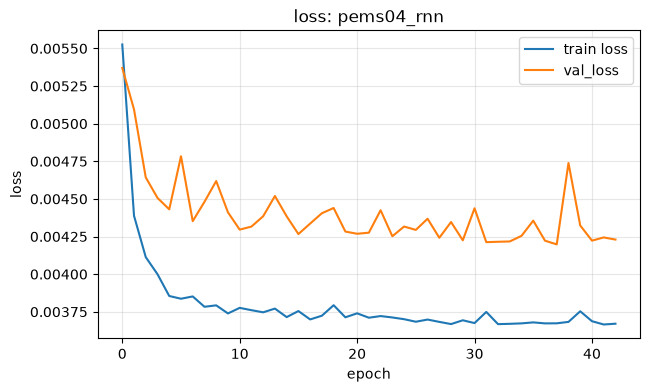

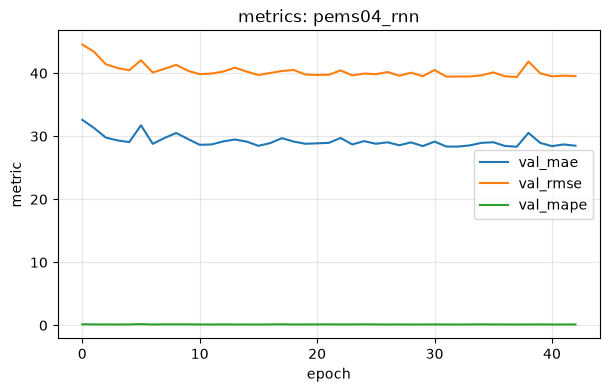

PosixPath('output/metrics_pems04_rnn.png')

In [13]:
torch.manual_seed(0)  # 固定随机种子，保证可复现
device = try_gpu()
train_loader, val_loader, test_loader, stats = get_pems04_dataloader(batch_size=64, sensor=0)  # 与实验报告对齐: 60/20/20

model = MyRNN(input_size=3, hidden_size=64, output_size=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    loss_fn=get_loss_fn("regression"),
    optimizer=optimizer,
    num_epochs=100,  # 加长训练 + 早停，让模型充分拟合
    task_type="regression",
    device=device,
    stats=stats,  # 传入后 MAE/RMSE/MAPE 在原始流量尺度上计算
    patience=20,
    min_delta=1e-4,
    grad_clip=5.0,
)

plot_loss_curve(history, "pems04_rnn")
plot_metric_curves(history, ["val_mae", "val_rmse", "val_mape"], "pems04_rnn")

### 2.torch实现RNN

In [11]:
# 封装接口 RNN: nn.RNN + Linear + LeakyReLU 输出头，超参数与手动实现完全一致
class TorchRNN(nn.Module):
    """nn.RNN(封装接口) + 输出头，forward 直接返回 (B, output_size)。"""

    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, output_size),
            nn.LeakyReLU(),
        )

    def forward(self, x):
        out, _ = self.rnn(x)  # out: (B, T, hidden)
        return self.head(out[:, -1, :])  # 取最后一步 -> (B, output_size)

epoch 001 | train loss 0.0739 | val loss 0.0403 | MAE 105.832606 | RMSE 122.105256 | MAPE 1.0292
epoch 002 | train loss 0.0192 | val loss 0.0079 | MAE 39.127850 | RMSE 53.933934 | MAPE 0.1893
epoch 003 | train loss 0.0060 | val loss 0.0064 | MAE 35.537880 | RMSE 48.632541 | MAPE 0.1719
epoch 004 | train loss 0.0050 | val loss 0.0057 | MAE 33.605055 | RMSE 45.836558 | MAPE 0.1604
epoch 005 | train loss 0.0046 | val loss 0.0053 | MAE 32.685579 | RMSE 44.261751 | MAPE 0.1622
epoch 006 | train loss 0.0044 | val loss 0.0051 | MAE 31.916168 | RMSE 43.344208 | MAPE 0.1564
epoch 007 | train loss 0.0043 | val loss 0.0050 | MAE 31.347399 | RMSE 42.961687 | MAPE 0.1463
epoch 008 | train loss 0.0042 | val loss 0.0050 | MAE 31.843219 | RMSE 42.778534 | MAPE 0.1738
epoch 009 | train loss 0.0041 | val loss 0.0049 | MAE 30.945838 | RMSE 42.670807 | MAPE 0.1388
epoch 010 | train loss 0.0041 | val loss 0.0048 | MAE 30.634930 | RMSE 42.306785 | MAPE 0.1395
epoch 011 | train loss 0.0040 | val loss 0.0048 

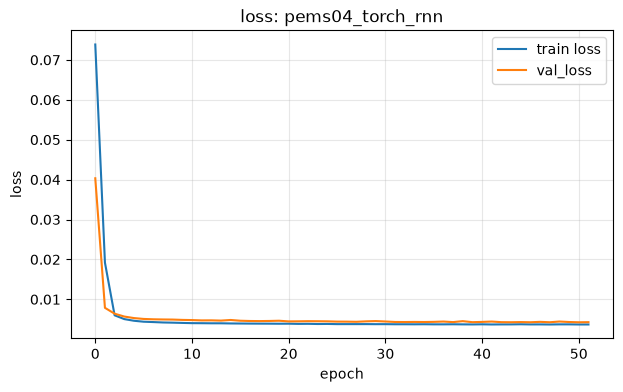

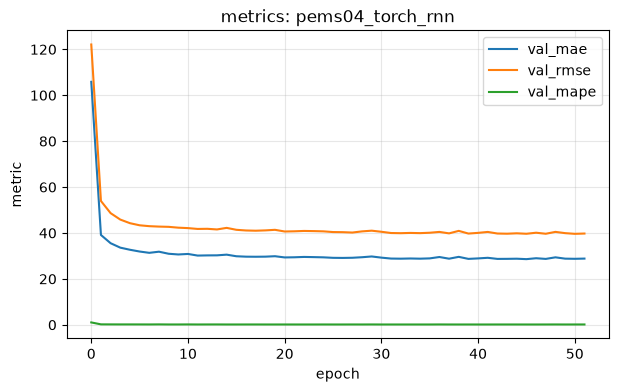

PosixPath('output/metrics_pems04_torch_rnn.png')

In [ ]:
device = try_gpu()
torch.manual_seed(0)  # 与手动实现同种子，保证可复现
train_loader, val_loader, test_loader, stats = get_pems04_dataloader(
    batch_size=64, sensor=0
)

model = TorchRNN(input_size=3, hidden_size=64, output_size=1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    loss_fn=get_loss_fn("regression"),
    optimizer=optimizer,
    num_epochs=100,
    task_type="regression",
    device=device,
    stats=stats,
    patience=20,
    min_delta=1e-4,
    grad_clip=5.0,
)

plot_loss_curve(history, "pems04_torch_rnn")
plot_metric_curves(history, ["val_mae", "val_rmse", "val_mape"], "pems04_torch_rnn")

### 3.超参数实验

In [13]:
# 3.1 hidden_size 对比: 固定 lr=1e-4, batch_size=64, patience=20
device = try_gpu()


def run_hp_experiment(hidden_size=64, lr=1e-4, batch_size=64, num_epochs=100, seed=0):
    """按给定超参数训练一次 torch RNN，返回关键指标与 history(3.1/3.2 共用)。"""
    torch.manual_seed(seed)
    train_loader, val_loader, test_loader, stats = get_pems04_dataloader(
        batch_size=batch_size, sensor=0
    )

    model = TorchRNN(input_size=3, hidden_size=hidden_size, output_size=1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        loss_fn=get_loss_fn("regression"),
        optimizer=optimizer,
        num_epochs=num_epochs,
        task_type="regression",
        device=device,
        stats=stats,
        patience=20,
        min_delta=1e-4,
        grad_clip=5.0,
    )

    # WAPE = test MAE / test 段流量均值(原始尺度)
    test_flow_mean = float("nan")
    if stats is not None:
        min_ = float(np.asarray(stats["min"]).reshape(-1)[0])
        max_ = float(np.asarray(stats["max"]).reshape(-1)[0])
        ys = torch.cat([y for _, y in test_loader])
        test_flow_mean = (ys * (max_ - min_) + min_).mean().item()

    return {
        "hidden_size": hidden_size,
        "lr": lr,
        "batch_size": batch_size,
        "best_epoch": history["best_epoch"],
        "best_val_loss": history["best_val_loss"],
        "test_mae": history["test_mae"],
        "test_rmse": history["test_rmse"],
        "test_mape": history["test_mape"],
        "test_wape": history["test_mae"] / test_flow_mean,
        "history": history,
    }

#### 3.1 隐藏层维度 hidden_size 对比

epoch 001 | train loss 0.1616 | val loss 0.0720 | MAE 139.857164 | RMSE 163.125465 | MAPE 0.7975
epoch 002 | train loss 0.0379 | val loss 0.0384 | MAE 103.180354 | RMSE 119.203066 | MAPE 0.9965
epoch 003 | train loss 0.0302 | val loss 0.0320 | MAE 93.476828 | RMSE 108.767039 | MAPE 0.9104
epoch 004 | train loss 0.0245 | val loss 0.0250 | MAE 81.868736 | RMSE 96.189687 | MAPE 0.7785
epoch 005 | train loss 0.0181 | val loss 0.0172 | MAE 66.792133 | RMSE 79.749370 | MAPE 0.6204
epoch 006 | train loss 0.0118 | val loss 0.0107 | MAE 50.909785 | RMSE 63.016361 | MAPE 0.4004
epoch 007 | train loss 0.0076 | val loss 0.0075 | MAE 39.163582 | RMSE 52.683525 | MAPE 0.2299
epoch 008 | train loss 0.0062 | val loss 0.0068 | MAE 35.988329 | RMSE 50.117571 | MAPE 0.1767
epoch 009 | train loss 0.0058 | val loss 0.0064 | MAE 34.760444 | RMSE 48.522901 | MAPE 0.1626
epoch 010 | train loss 0.0054 | val loss 0.0060 | MAE 33.922099 | RMSE 47.130145 | MAPE 0.1582
epoch 011 | train loss 0.0051 | val loss 0.00

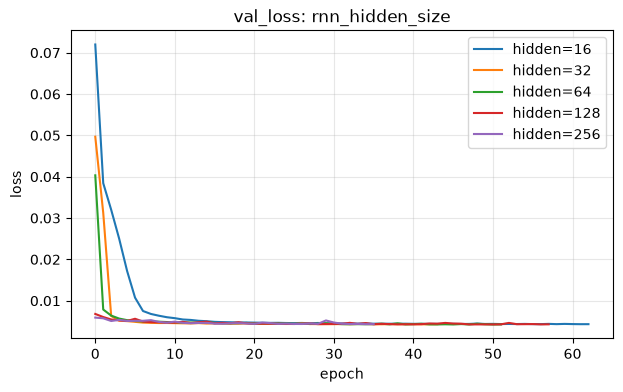

PosixPath('output/val_loss_rnn_hidden_size.png')

In [13]:
hidden_sizes = [16, 32, 64, 128, 256]
hs_results = [run_hp_experiment(hidden_size=hs, lr=1e-4) for hs in hidden_sizes]

print("=== 3.1 hidden_size 对比(固定 lr=1e-4, batch_size=64) ===")
print(hp_summary_table(hs_results).to_string(index=False))

plot_loss_curves(
    history_list=[r["history"] for r in hs_results],
    task_list=[f"hidden={hs}" for hs in hidden_sizes],
    fig_name="rnn_hidden_size",
    loss_key="val_loss",
)

| hidden_size | test MAE | test RMSE | test MAPE% | test WAPE% | 观察 |
|---|---|---|---|---|---|
| 16 | 27.60 | 38.41 | 13.48 | 10.97 | 略差(容量偏小) |
| 32 | 27.49 | 38.39 | 13.21 | 10.93 | 持平 |
| 64(基线) | 27.30 | 38.12 | 13.01 | 10.85 | 持平 |
| 128 | **27.21** | **38.05** | 13.20 | **10.81** | 名义最优 |
| 256 | 27.78 | 38.55 | **14.29** | 11.04 | 反而略降 |

- 容量饱和:hidden 32~128 的 MAE 只差 0.3,best_val_loss 全部是 0.0043~0.0044——单传感器、12 步窗口、预测下一步,这个任务本身简单,64 维已足够,模型不是受容量限制的。
- 不是越大越好:256 反而最差(MAE 27.78、MAPE 14.29%),而且 best_epoch=17 最早触发平台——容量过剩后更容易在验证集上过早停滞,还更慢。这正好是"模型容量与任务复杂度匹配"的典型例子。
- 128 名义最优但优势可忽略(0.3%)。

#### 3.2 学习率 lr 对比

epoch 001 | train loss 0.0739 | val loss 0.0403 | MAE 105.832606 | RMSE 122.105256 | MAPE 1.0292
epoch 002 | train loss 0.0192 | val loss 0.0079 | MAE 39.127850 | RMSE 53.933934 | MAPE 0.1893
epoch 003 | train loss 0.0060 | val loss 0.0064 | MAE 35.537880 | RMSE 48.632541 | MAPE 0.1719
epoch 004 | train loss 0.0050 | val loss 0.0057 | MAE 33.605055 | RMSE 45.836558 | MAPE 0.1604
epoch 005 | train loss 0.0046 | val loss 0.0053 | MAE 32.685579 | RMSE 44.261751 | MAPE 0.1622
epoch 006 | train loss 0.0044 | val loss 0.0051 | MAE 31.916168 | RMSE 43.344208 | MAPE 0.1564
epoch 007 | train loss 0.0043 | val loss 0.0050 | MAE 31.347399 | RMSE 42.961687 | MAPE 0.1463
epoch 008 | train loss 0.0042 | val loss 0.0050 | MAE 31.843219 | RMSE 42.778534 | MAPE 0.1738
epoch 009 | train loss 0.0041 | val loss 0.0049 | MAE 30.945838 | RMSE 42.670807 | MAPE 0.1388
epoch 010 | train loss 0.0041 | val loss 0.0048 | MAE 30.634930 | RMSE 42.306785 | MAPE 0.1395
epoch 011 | train loss 0.0040 | val loss 0.0048 

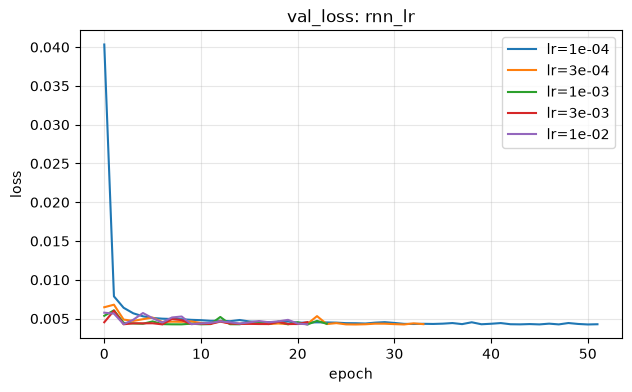

PosixPath('output/val_loss_rnn_lr.png')

In [14]:
# 3.2 lr 对比: 固定 hidden_size=64, batch_size=64, patience=20
lr_list = [1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
lr_results = [run_hp_experiment(hidden_size=64, lr=lr) for lr in lr_list]

print("=== 3.2 lr 对比(固定 hidden_size=64, batch_size=64) ===")
print(hp_summary_table(lr_results).to_string(index=False))

plot_loss_curves(
    history_list=[r["history"] for r in lr_results],
    task_list=[f"lr={lr:.0e}" for lr in lr_list],
    fig_name="rnn_lr",
    loss_key="val_loss",
)

## LSTM和GRU实验

### 1. 实验设定
- 数据集:FS_NYC(Foursquare NYC 签到),任务为多分类——根据用户最近 `seq_len=12` 次签到,
  预测下一次签到的 `venueId`(训练集约 2.9 万类别)。
- 输入特征:venueId 索引序列 -> `nn.Embedding`;经纬度连续特征(z-score 归一化)与 embedding 拼接。
- 模型:同一套结构分别使用 `nn.LSTM` 与 `nn.GRU`,其余超参数完全一致,公平对比。
- 正则化:embedding/分类头 Dropout=0.3 + AdamW weight_decay=1e-4 + 标签平滑 0.1。
  原因:3 万类全量分类极易过拟合——模型会背下用户训练期的轨迹,
  train acc@1 可冲到 70% 而 val loss 从第 6 轮起持续回升(最佳轮次反而很早)。
- 评估:验证集上早停(patience=20),训练结束后用最佳权重在测试集上报告 Acc@1 / Acc@5。
  频率先验基线(始终猜训练集最高频 venue)acc@1≈0.5%、acc@5≈1.8%;
  模型 Acc@1 落在 5%~15%、Acc@5 落在 20%~40% 属于合理范围。

### 2. 模型定义:Embedding + 经纬度 + LSTM/GRU

In [14]:
# 通用 next-POI 模型:venueId Embedding + 经纬度连续特征 -> LSTM/GRU -> 分类头
class VenueRNN(nn.Module):
    """
    - venueId 索引序列 -> nn.Embedding
    - embedding 与经纬度连续特征拼接后输入 LSTM/GRU
    - 取最后一步隐藏状态 -> Dropout -> Linear 分类头
    rnn_type: "lstm" 或 "gru";结构与超参数仅 RNN 单元不同。
    dropout: embedding 输出与分类头输入上的 dropout 比率,
    用于抑制 3 万类全量分类的过拟合(默认 0.3)。
    """

    def __init__(self, num_venues, num_classes, embed_dim=32, hidden_size=64,
                 num_layers=1, rnn_type="lstm", dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(num_venues, embed_dim)
        self.embed_dropout = nn.Dropout(dropout)
        rnn_cls = nn.LSTM if rnn_type == "lstm" else nn.GRU
        self.rnn = rnn_cls(
            input_size=embed_dim + 2,  # embedding 输出 + 经纬度两维
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
        )
        self.head_dropout = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        cat_x, cont_x = x  # cat: (B, T) long; cont: (B, T, 2) float
        emb = self.embed_dropout(self.embedding(cat_x))  # (B, T, embed_dim)
        rnn_in = torch.cat([emb, cont_x], dim=-1)  # (B, T, embed_dim+2)
        out, _ = self.rnn(rnn_in)  # out: (B, T, hidden_size)
        return self.head(self.head_dropout(out[:, -1, :]))  # -> (B, num_classes)

### 3. 数据加载与实验配置

In [16]:
torch.manual_seed(0)  # 固定随机种子，保证可复现

# 数据加载:按用户时间顺序切分 train 60% / val 20% / test 20%
train_loader, val_loader, test_loader, metadata = get_fs_nyc_dataloader(
    seq_len=12,
    batch_size=64,
    train_ratio=0.6,
    val_ratio=0.2,
)

device = try_gpu()
print("num_venues   =", metadata["num_venues"])
print("num_classes  =", metadata["num_classes"])
print(
    "样本数: train", len(train_loader.dataset),
    "| val", len(val_loader.dataset),
    "| test", len(test_loader.dataset),
)

# 两个模型结构完全一致,仅 RNN 单元不同(LSTM vs GRU)
common_config = {"embed_dim": 32, "hidden_size": 64, "num_layers": 1, "dropout": 0.3}

lstm_model = VenueRNN(
    num_venues=metadata["num_venues"],
    num_classes=metadata["num_classes"],
    rnn_type="lstm",
    **common_config,
).to(device)

gru_model = VenueRNN(
    num_venues=metadata["num_venues"],
    num_classes=metadata["num_classes"],
    rnn_type="gru",
    **common_config,
).to(device)

print("LSTM params =", sum(p.numel() for p in lstm_model.parameters()))
print("GRU  params =", sum(p.numel() for p in gru_model.parameters()))


def run_venue_experiment(
    model,
    name,
    train_loader,
    val_loader,
    test_loader,
    device,
    config,
    lr=1e-3,
    num_epochs=50,
    patience=20,
    grad_clip=5.0,
    weight_decay=1e-4,
    label_smoothing=0.1,
):
    """
    跑一次 FS_NYC 多分类实验,返回 {"name", "config", "history"} 供对比。
    正则化:模型内 Dropout + AdamW weight_decay + CrossEntropyLoss 标签平滑,
    用于抑制 3 万类全量分类的过拟合。
    """
    torch.manual_seed(0)  # 每次实验固定种子,保证可复现
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    history = train_model(
        model=model,
        train_loader=train_loader,
        test_loader=test_loader,
        loss_fn=nn.CrossEntropyLoss(label_smoothing=label_smoothing),
        optimizer=optimizer,
        num_epochs=num_epochs,
        task_type="multiclass",
        device=device,
        val_loader=val_loader,
        top_k=(1, 5),
        patience=patience,
        grad_clip=grad_clip,
    )
    return {"name": name, "config": config, "history": history}

num_venues   = 29351
num_classes  = 29350
样本数: train 123027 | val 27782 | test 27481
LSTM params = 2872582
GRU  params = 2866182


### 4. 训练 LSTM

In [17]:
# === 4.1 LSTM ===
lstm_summary = run_venue_experiment(
    model=lstm_model,
    name="LSTM",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    config={"rnn": "LSTM", **common_config, "batch_size": 64, "seq_len": 12, "lr": 1e-3},
    lr=1e-3,
    num_epochs=50,
    patience=20,
    grad_clip=5.0,
)

epoch 001 | train loss 9.5677 | val loss 8.7230 | train acc@1 0.0122 | val acc@1 0.0329 | train acc@5 0.0365 | val acc@5 0.0903
epoch 002 | train loss 8.6499 | val loss 8.0503 | train acc@1 0.0483 | val acc@1 0.0772 | train acc@5 0.1193 | val acc@5 0.1858
epoch 003 | train loss 8.0668 | val loss 7.6193 | train acc@1 0.0827 | val acc@1 0.1045 | train acc@5 0.1923 | val acc@5 0.2479
epoch 004 | train loss 7.6307 | val loss 7.3501 | train acc@1 0.1062 | val acc@1 0.1174 | train acc@5 0.2443 | val acc@5 0.2819
epoch 005 | train loss 7.3006 | val loss 7.1722 | train acc@1 0.1224 | val acc@1 0.1293 | train acc@5 0.2794 | val acc@5 0.3039
epoch 006 | train loss 7.0391 | val loss 7.0515 | train acc@1 0.1341 | val acc@1 0.1333 | train acc@5 0.3060 | val acc@5 0.3188
epoch 007 | train loss 6.8220 | val loss 6.9653 | train acc@1 0.1435 | val acc@1 0.1408 | train acc@5 0.3261 | val acc@5 0.3301
epoch 008 | train loss 6.6426 | val loss 6.9045 | train acc@1 0.1517 | val acc@1 0.1441 | train acc@5 0.

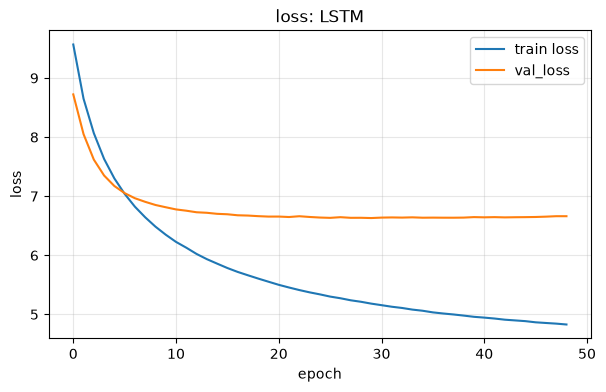

PosixPath('output/loss_LSTM.png')

In [18]:
plot_loss_curve(lstm_summary["history"], lstm_summary["name"])

### 5. 训练 GRU

In [19]:
# === 5.1 GRU ===
gru_summary = run_venue_experiment(
    model=gru_model,
    name="GRU",
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    config={"rnn": "GRU", **common_config, "batch_size": 64, "seq_len": 12, "lr": 1e-3},
    lr=1e-3,
    num_epochs=50,
    patience=20,
    grad_clip=5.0,
)

epoch 001 | train loss 9.5681 | val loss 8.7082 | train acc@1 0.0123 | val acc@1 0.0312 | train acc@5 0.0365 | val acc@5 0.0838
epoch 002 | train loss 8.6510 | val loss 8.0325 | train acc@1 0.0483 | val acc@1 0.0790 | train acc@5 0.1186 | val acc@5 0.1908
epoch 003 | train loss 8.0466 | val loss 7.5851 | train acc@1 0.0856 | val acc@1 0.1112 | train acc@5 0.1970 | val acc@5 0.2553
epoch 004 | train loss 7.6006 | val loss 7.3135 | train acc@1 0.1108 | val acc@1 0.1264 | train acc@5 0.2510 | val acc@5 0.2911
epoch 005 | train loss 7.2675 | val loss 7.1291 | train acc@1 0.1270 | val acc@1 0.1354 | train acc@5 0.2874 | val acc@5 0.3133
epoch 006 | train loss 7.0074 | val loss 7.0018 | train acc@1 0.1376 | val acc@1 0.1403 | train acc@5 0.3142 | val acc@5 0.3288
epoch 007 | train loss 6.7997 | val loss 6.9108 | train acc@1 0.1467 | val acc@1 0.1467 | train acc@5 0.3321 | val acc@5 0.3395
epoch 008 | train loss 6.6210 | val loss 6.8531 | train acc@1 0.1538 | val acc@1 0.1481 | train acc@5 0.

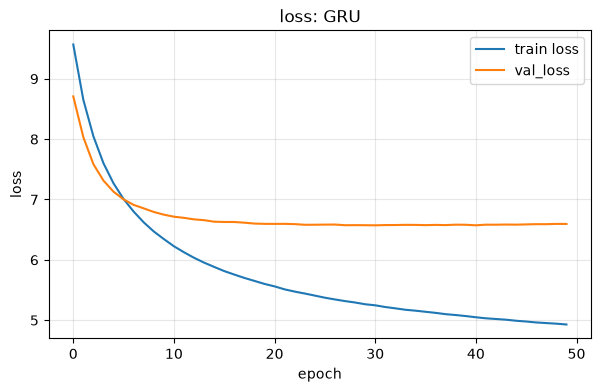

PosixPath('output/loss_GRU.png')

In [20]:
plot_loss_curve(gru_summary["history"], gru_summary["name"])

### 6. 对比分析
- 汇总表对比 `best_epoch`(收敛速度)、`best_val_loss`、测试集 `Acc@1` / `Acc@5`(最终精度);
- loss / Acc@1 曲线对比训练过程:谁收敛更快、谁更稳定(曲线是否抖动);
- 注意参数量差异:LSTM 的循环部分约为 GRU 的 1.5 倍,可结合单轮耗时讨论取舍;
- 出现过拟合时(train loss 持续下降而 val loss 回升),应比较早停最优轮次的指标;
  同时用频率先验基线做参照,判断模型是否学到了超越"猜高频地点"的迁移性规律。

频率先验基线(始终猜训练集最高频 venue):
split  prior_acc@1  prior_acc@5
train       0.0051       0.0163
  val       0.0051       0.0177
 test       0.0052       0.0203



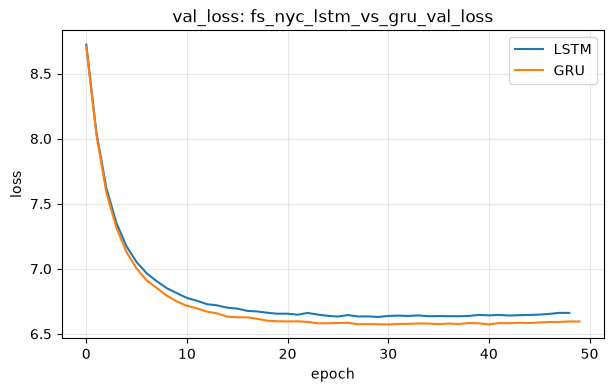

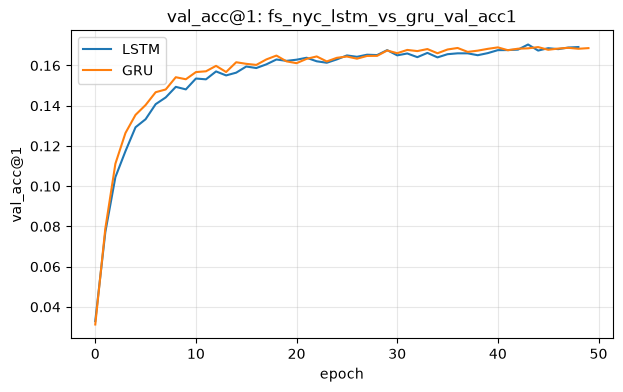

,model,rnn,best_epoch,best_val_loss,test_loss,test_acc@1,test_acc@5
0,LSTM,LSTM,30,6.6300,7.0800,0.1379,0.3206
1,GRU,GRU,31,6.5721,7.0079,0.1419,0.3284


In [21]:
summaries = [lstm_summary, gru_summary]

# --- 频率先验基线:始终预测训练集最高频的 venue ---
train_y = train_loader.dataset.labels.numpy()
val_y = val_loader.dataset.labels.numpy()
test_y = test_loader.dataset.labels.numpy()

freq = np.bincount(train_y, minlength=metadata["num_classes"])
order = np.argsort(-freq)
top1, top5 = order[:1], order[:5]

prior_df = pd.DataFrame(
    [
        {
            "split": name,
            "prior_acc@1": round(np.isin(y, top1).mean(), 4),
            "prior_acc@5": round(np.isin(y, top5).mean(), 4),
        }
        for name, y in [("train", train_y), ("val", val_y), ("test", test_y)]
    ]
)
print("频率先验基线(始终猜训练集最高频 venue):")
print(prior_df.to_string(index=False))
print()

# 训练过程对比:验证集 loss 与 Acc@1 曲线
plot_loss_curves(
    [s["history"] for s in summaries],
    [s["name"] for s in summaries],
    fig_name="fs_nyc_lstm_vs_gru_val_loss",
    loss_key="val_loss",
)

plot_metric_curves_multi(
    [s["history"] for s in summaries],
    [s["name"] for s in summaries],
    metric_key="val_acc@1",
    fig_name="fs_nyc_lstm_vs_gru_val_acc1",
)

# 汇总表:模型 / best_epoch / best_val_loss / 最终测试 Acc@1 / Acc@5
model_compare_table(summaries, config_keys=("rnn",))